In [128]:
## 1. Modeling and backtesting using ML models:

# The objective of this notebook is to use the engineered features from Notebook 3 to build a predictive model for market direction and evaluate whether the resulting signals can support a simple trading strategy. 
# I use a time-series modeling framework to generate out-of-sample predictions, convert them into trading positions, and compare strategy performance against a buy-and-hold benchmark.

In [129]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from  pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.linear_model import LogisticRegression

In [130]:
## 2. Set project paths Load preprocessed data
project_root = Path.cwd().parent
processed_data_path = project_root / "data" / "processed"
combined_features = pd.read_csv(processed_data_path / "combined_features.csv", index_col=0, parse_dates=True)
clean_close_prices = pd.read_csv(processed_data_path / "clean_close_prices.csv", index_col=0, parse_dates=True)
combined_features.head()

,AAPL_ret,ABBV_ret,ACN_ret,ADBE_ret,AMZN_ret,AVGO_ret,BAC_ret,BRK-B_ret,COST_ret,CRM_ret,...,NFLX_lag5,NVDA_lag5,PEP_lag5,PG_lag5,SPY_lag5,TMO_lag5,UNH_lag5,V_lag5,WMT_lag5,XOM_lag5
Date,,,,,,,,,,,,,,,,,,,,,
2018-03-29,0.007809,0.004031,0.041313,0.016656,0.011122,-0.004352,0.020415,0.014288,0.026251,0.030298,...,-0.030902,-0.026996,-0.007357,-0.008177,-0.024997,-0.026437,-0.034153,-0.026213,-0.011794,-0.020522
2018-04-02,-0.006556,-0.033703,-0.035961,-0.017586,-0.052061,-0.033821,-0.022674,-0.022458,-0.030144,-0.008598,...,-0.018781,-0.036717,-0.016584,-0.006544,-0.021315,-0.012926,-0.012360,-0.024919,-0.019738,-0.008299
2018-04-03,0.010259,-0.009512,0.005474,0.017194,0.014621,0.039968,0.009553,0.015180,-0.000766,0.010321,...,0.064498,0.049405,0.006218,0.006587,0.027359,0.024579,0.030675,0.031111,0.024350,0.015228
2018-04-04,0.019122,0.025941,0.007931,0.042236,0.013304,0.000887,0.009801,0.010861,0.015936,0.025668,...,-0.061370,-0.077552,0.007771,0.018061,-0.017012,-0.014594,-0.005067,-0.026857,-0.016572,-0.004054
2018-04-05,0.006935,-0.007854,0.010669,-0.006710,0.029194,-0.002869,0.014726,0.003698,0.003935,-0.003683,...,-0.049619,-0.018491,0.014307,0.013498,-0.002955,-0.003388,0.002478,-0.003493,0.019988,-0.012076


In [131]:
## 3. Set next-day SPY return as target and align with combined features
spy_returns = clean_close_prices["SPY"].pct_change()
target = (spy_returns.shift(-1) > 0).astype(int)
target.name = "target"
ML_dataset = combined_features.join(target, how="inner")
ML_dataset = ML_dataset.dropna()
ML_dataset.head()

,AAPL_ret,ABBV_ret,ACN_ret,ADBE_ret,AMZN_ret,AVGO_ret,BAC_ret,BRK-B_ret,COST_ret,CRM_ret,...,NVDA_lag5,PEP_lag5,PG_lag5,SPY_lag5,TMO_lag5,UNH_lag5,V_lag5,WMT_lag5,XOM_lag5,target
Date,,,,,,,,,,,,,,,,,,,,,
2018-03-29,0.007809,0.004031,0.041313,0.016656,0.011122,-0.004352,0.020415,0.014288,0.026251,0.030298,...,-0.026996,-0.007357,-0.008177,-0.024997,-0.026437,-0.034153,-0.026213,-0.011794,-0.020522,0
2018-04-02,-0.006556,-0.033703,-0.035961,-0.017586,-0.052061,-0.033821,-0.022674,-0.022458,-0.030144,-0.008598,...,-0.036717,-0.016584,-0.006544,-0.021315,-0.012926,-0.012360,-0.024919,-0.019738,-0.008299,1
2018-04-03,0.010259,-0.009512,0.005474,0.017194,0.014621,0.039968,0.009553,0.015180,-0.000766,0.010321,...,0.049405,0.006218,0.006587,0.027359,0.024579,0.030675,0.031111,0.024350,0.015228,1
2018-04-04,0.019122,0.025941,0.007931,0.042236,0.013304,0.000887,0.009801,0.010861,0.015936,0.025668,...,-0.077552,0.007771,0.018061,-0.017012,-0.014594,-0.005067,-0.026857,-0.016572,-0.004054,1
2018-04-05,0.006935,-0.007854,0.010669,-0.006710,0.029194,-0.002869,0.014726,0.003698,0.003935,-0.003683,...,-0.018491,0.014307,0.013498,-0.002955,-0.003388,0.002478,-0.003493,0.019988,-0.012076,0


In [132]:
## 4. Split ML dataset into "Features" and "Target"
X = ML_dataset.drop(columns="target")
y = ML_dataset["target"]

In [133]:
## 5. Split "Data" into test/train based on Time
split_index = int(len(ML_dataset)*0.8)
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

In [134]:
## 6. Start with Logistics Regression as baseline model
logreg_model = LogisticRegression(max_iter=1000)
logreg_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [135]:
## 7. Generate and evaluate predictions
y_pred = logreg_model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print(classification_report(y_test, y_pred))

Accuracy: 0.511166253101737
              precision    recall  f1-score   support

           0       0.45      0.46      0.45       178
           1       0.56      0.56      0.56       225

    accuracy                           0.51       403
   macro avg       0.51      0.51      0.51       403
weighted avg       0.51      0.51      0.51       403



In [136]:
## 8. Convert predictions into trading positions
trading_positions = pd.Series(y_pred, index=y_test.index)
trading_positions = trading_positions.replace({0:-1, 1:1})
trading_positions = trading_positions.shift(1)

In [137]:
## 9. Compute strategy returns and benchmark returns
spy_test_returns = spy_returns.loc[y_test.index]
strategy_returns = trading_positions * spy_test_returns
strategy_returns = strategy_returns.dropna()
benchmark_returns = spy_test_returns. loc[strategy_returns.index]

In [138]:
## 10. Compute strategy cumulative returns and benchmark cumulative returns
cum_strategy = (1 + strategy_returns).cumprod()
cum_benchmark = (1 + benchmark_returns).cumprod()

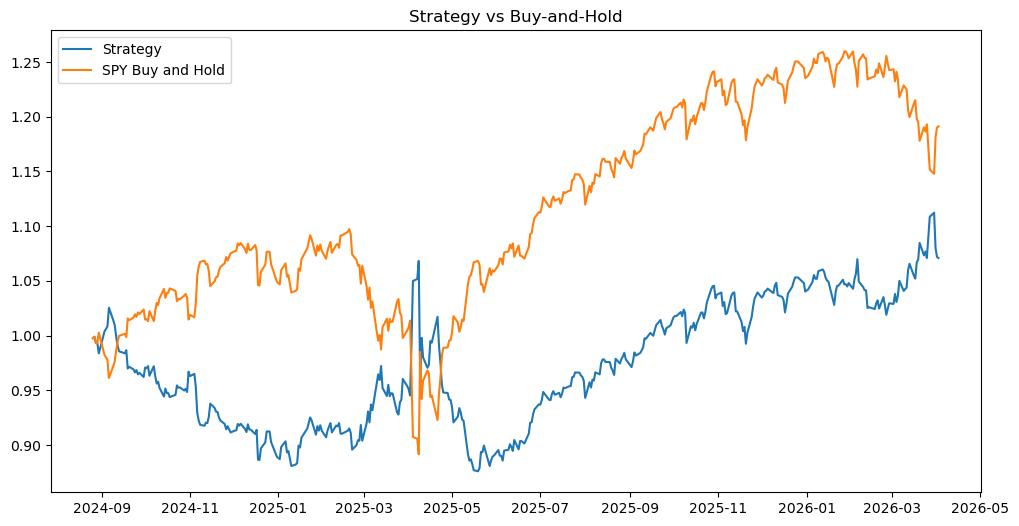

In [139]:
## 11. Visulalize performance
plt.figure(figsize=(12, 6))
plt.plot(cum_strategy, label="Strategy")
plt.plot(cum_benchmark, label="SPY Buy and Hold")
plt.legend()
plt.title("Strategy vs Buy-and-Hold")
plt.show()

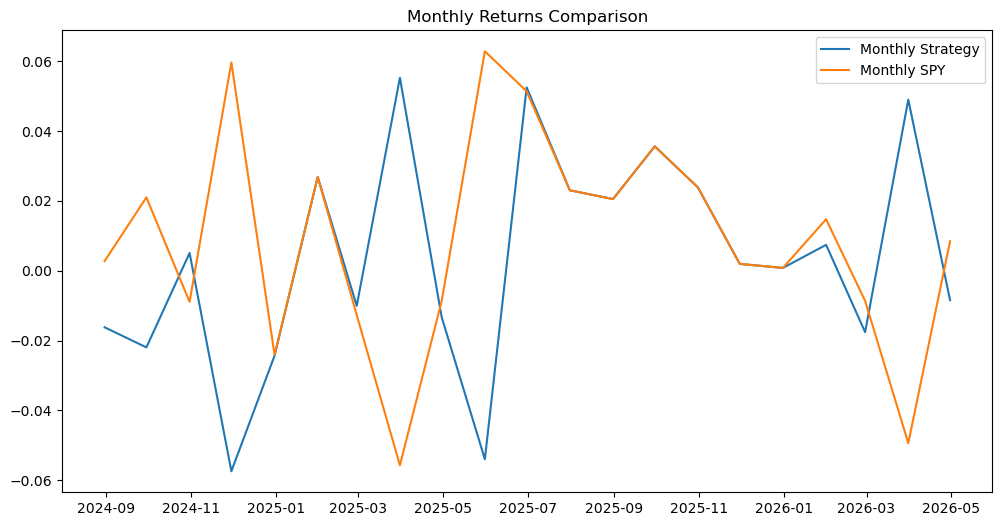

In [140]:
## 12. Monthly analysis
def monthly_return(x):
    return (1+x).prod()-1
monthly_strategy = strategy_returns.resample("ME").apply(monthly_return)
monthly_benchmark = benchmark_returns.resample("ME").apply(monthly_return)
plt.figure(figsize=(12, 6))
plt.plot(monthly_strategy, label="Monthly Strategy")
plt.plot(monthly_benchmark, label="Monthly SPY")
plt.legend()
plt.title("Monthly Returns Comparison")
plt.show()

In [141]:
## 13. Risk metrics
sharpe = strategy_returns.mean() / strategy_returns.std() * (252 ** 0.5)
drawdown = (cum_strategy - cum_strategy.cummax()) / cum_strategy.cummax()
max_drawdown = drawdown.min()
print("Sharpe Ratio:", sharpe)
print("Max Drawdown:", max_drawdown)

Sharpe Ratio: 0.33488490917939234
Max Drawdown: -0.17991765520873051


In [142]:
## 14. Logistic Regression Modeling and backtesting Conclusion:

# I developed a baseline long/short trading strategy using logistic regression and evaluated its performance against a buy-and-hold benchmark. 
# The results show a positive but modest edge, with suboptimal risk-adjusted returns, indicating that the signal is present but not yet robust. 
# This establishes a solid foundation for further improvements in feature design, signal filtering, and model sophistication.

In [111]:
processed_returns_path = project_root / "data" / "processed"
processed_returns_path.mkdir(parents=True, exist_ok=True)
strategy_returns.to_csv(processed_returns_path / "strategy_returns.csv", index=True)
benchmark_returns.to_csv(processed_returns_path / "benchmark_returns.csv", index=True)